In [10]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv('credit_card_fraud.csv')
df.head(2)

X = df.drop('is_fraud' , axis = 1)
y= df['is_fraud']

X_train , X_test , y_train , y_test = train_test_split (
    X , y , test_size = 0.2 , random_state = 42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Test set class distribution:\n", y_test.value_counts())

Accuracy: 1.0
Test set class distribution:
 is_fraud
0    376
1     24
Name: count, dtype: int64


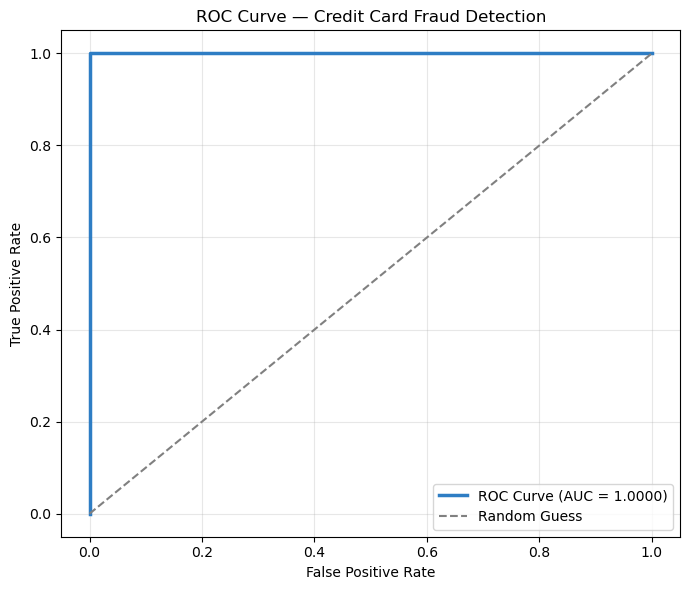

AUC Score: 1.0000


In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test_s)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2E7DC4', lw=2.5, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Card Fraud Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

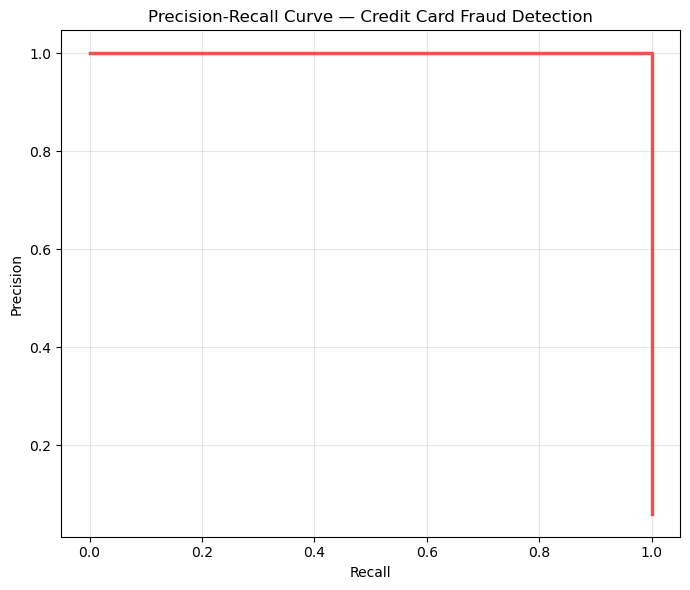

In [12]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='#E8554E', lw=2.5)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Credit Card Fraud Detection')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import log_loss

loss = log_loss(y_test, y_proba)
print(f"Log Loss: {loss:.4f}")

Log Loss: 0.0025
